<a href="https://colab.research.google.com/github/Anisha2810/Neural-networks-and-deep-learning/blob/main/object_detection_using_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


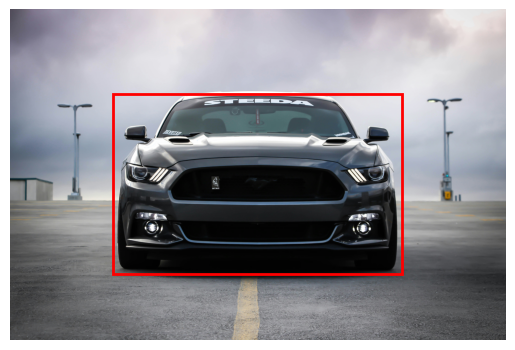

In [4]:
# Install (run once in Colab)
!pip -q install torch torchvision pillow matplotlib requests

import torch
import torchvision
from torchvision.transforms import ToTensor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
from io import BytesIO

# Load CNN-based model (Faster R-CNN)
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

# Load image from internet (car image)
url = "https://images.unsplash.com/photo-1494976388531-d1058494cdd8"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

# Convert image to tensor
img_tensor = ToTensor()(img)

# Run detection
with torch.no_grad():
    pred = model([img_tensor])

# Show image
fig, ax = plt.subplots(1)
ax.imshow(img)

# Draw bounding boxes
for box, score in zip(pred[0]['boxes'], pred[0]['scores']):
    if score > 0.5:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            edgecolor='red', facecolor='none', linewidth=2
        )
        ax.add_patch(rect)

plt.axis('off')
plt.show()